-----------------------------------------------------------------

# **AI Module Lab - Encoder-Decoder**

We would be trying our hands on building a  **BERT**  (Bidirectional Encoder Representation from Transformer) and **GPT** (Generative Pre-trained Transformer)miniature models.

------------------------------------------------------------

--------------------------------------------------

# GPT-style Transformer

1. Imports, Seeds, Device Selection, and Corpus

Modern machine learning requires reproducibility and hardware acceleration. The first step is importing essential libraries, fixing random seeds, and selecting the device.


Imports

torch provides tensors and neural network tools.

torch.nn contains neural network layers.

torch.optim includes optimizers such as AdamW.

random and torch.manual_seed() ensure deterministic behavior.

Seeding

Setting a seed stabilizes:

weight initialization

data shuffling

dropout randomness

This allows you to reproduce results exactly.

Device selection

Checks whether a GPU is available. GPUs greatly accelerate matrix operations.

In [1]:
# Imports, Seed, Device, Corpus

import math
import random
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cpu


##  2. Creating a Tiny Text Corpus

This model trains on a very small set of sentences.

This tiny corpus allows:
fast experimentation,
understanding Transformer behavior,
verifying generation.
A small dataset also helps beginners visualize embedding size, vocabulary, and attention.

In [3]:

# Tiny text corpus

corpus = [
    "i love deep learning",
    "i love transformers",
    "i love machine learning",
    "transformers are powerful models",
    "attention is all you need",
    "sequence models learn dependencies",
    "neural networks can generate text",
    "language models predict next words",
    "pytorch makes building models easy",
    "we train models with gradient descent",
    # You can add more lines, e.g.:
    # "i train neural networks",
    # "neural networks are trained with gradient descent",
]

print("Corpus:")
for s in corpus:
    print("  ", s)


Corpus:
   i love deep learning
   i love transformers
   i love machine learning
   transformers are powerful models
   attention is all you need
   sequence models learn dependencies
   neural networks can generate text
   language models predict next words
   pytorch makes building models easy
   we train models with gradient descent


## 3. Tokenization, Vocabulary, Encoding, and Padding


Transformers cannot process raw text. They require numeric IDs.

3.1 Special Tokens

`<PAD>`: used to fill empty sequence space

`<UNK>`: unknown words

`<SOS>`: start-of-sequence

`<EOS>`: end-of-sequence

The vocabulary maps every word to an integer. The inverse vocabulary maps integers back to words during decoding.

In [4]:
# Tokenization, Vocabulary, Encoding, Padding

# Tokenization & vocabulary

SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]

def tokenize(text: str):
    return text.lower().strip().split()

# collect all words from corpus
vocab_words = set()
for line in corpus:
    vocab_words.update(tokenize(line))

words = SPECIAL_TOKENS + sorted(list(vocab_words))
vocab = {w: i for i, w in enumerate(words)}
inv_vocab = {i: w for w, i in vocab.items()}

PAD_IDX = vocab["<PAD>"]
UNK_IDX = vocab["<UNK>"]
SOS_IDX = vocab["<SOS>"]
EOS_IDX = vocab["<EOS>"]

print("\nVocab size:", len(vocab))
print("Vocab:", vocab)





Vocab size: 39
Vocab: {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, 'all': 4, 'are': 5, 'attention': 6, 'building': 7, 'can': 8, 'deep': 9, 'dependencies': 10, 'descent': 11, 'easy': 12, 'generate': 13, 'gradient': 14, 'i': 15, 'is': 16, 'language': 17, 'learn': 18, 'learning': 19, 'love': 20, 'machine': 21, 'makes': 22, 'models': 23, 'need': 24, 'networks': 25, 'neural': 26, 'next': 27, 'powerful': 28, 'predict': 29, 'pytorch': 30, 'sequence': 31, 'text': 32, 'train': 33, 'transformers': 34, 'we': 35, 'with': 36, 'words': 37, 'you': 38}


## Encode Sentences with `<SOS>` and `<EOS>`

`<SOS>` helps during generation.

`<EOS>` tells the model when a sentence ends.

Unknown words map to `<UNK>`.

In [5]:
# Encode sentences and pad

def encode_sentence(sentence: str):
    tokens = tokenize(sentence)
    ids = [SOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    return ids

encoded_corpus = [encode_sentence(s) for s in corpus]



### Padding Sequences to Equal Length

### Why padding?

### Transformers process batches with fixed length. Padding ensures all sequences share the same shape.

In [6]:
def pad_sequences(sequences, pad_value=PAD_IDX):
    max_len = max(len(seq) for seq in sequences)
    padded = [seq + [pad_value] * (max_len - len(seq)) for seq in sequences]
    return torch.tensor(padded, dtype=torch.long)

data = pad_sequences(encoded_corpus, PAD_IDX).to(device)  # (B, T)
B, T = data.size()
vocab_size = len(vocab)

print("\nData shape (batch, time):", data.shape)



Data shape (batch, time): torch.Size([10, 8])


# Masks and Encode/Decode Utilities

### We need masks to:

### prevent attending to future tokens (causal LM), avoid attending to padding tokens.

Causal mask: Prevents cheating during training.

Padding mask: Ensures <PAD> tokens contribute nothing to attention.

In [7]:

# Mask helpers: boolean causal + padding mask

def get_masks(T, src):
    """
    T: sequence length
    src: (B, T) tensor of token ids
    Returns:
      attn_mask: (T, T) bool, True = DISALLOWED (causal)
      pad_mask:  (B, T) bool, True = PAD positions
    """
    # causal: upper triangle (j > i) is True (block attention)
    attn_mask = torch.triu(
        torch.ones(T, T, dtype=torch.bool, device=src.device), diagonal=1
    )
    pad_mask = (src == PAD_IDX)  # True at PAD positions
    return attn_mask, pad_mask




## Encode/Decode

In [8]:

# Shared encode/decode helpers for generation

def encode_tokens(text: str):
    tokens = tokenize(text)
    return [SOS_IDX] + [vocab.get(t, UNK_IDX) for t in tokens]

def decode_tokens(token_ids):
    words_decoded = []
    for tid in token_ids:
        if tid in [SOS_IDX, EOS_IDX, PAD_IDX]:
            continue
        words_decoded.append(inv_vocab[tid])
    return " ".join(words_decoded)

# GPT-2 Style Transformer Block

This is the core computational building block.

Key concepts

Pre-LayerNorm: improves training stability.

Multi-head attention: allows the model to capture multiple relationships.

Feed-forward network: increases representational power.

Residual connections: prevent gradient vanishing.

GELU activation: smoother alternative to ReLU.

.........

This structure mirrors GPT-2:

- token + position embeddings
- stack of Transformer blocks
- final normalization
- output projection -> logits over vocabulary

Full GPT-Style Language Model

In [9]:
# GPT-2-Style Transformer Block & Model


# GPT-2-style Transformer LM
#  - learned positional embeddings
#  - pre-norm (LayerNorm before each sub-block)
#  - GELU (Gaussian Error Linear Unit) activation


class GPT2Block(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=False)

        self.ln_2 = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, dim_feedforward)
        self.fc2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.GELU()

    def forward(self, x, attn_mask=None, key_padding_mask=None):
        """
        x: (T, B, d_model)
        attn_mask: (T, T) bool, True = disallowed (causal)
        key_padding_mask: (B, T) bool, True = PAD
        """
        # Self-attention with pre-norm
        norm_x = self.ln_1(x)
        attn_out, _ = self.attn(
            norm_x, norm_x, norm_x,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask
        )
        x = x + attn_out

        # Feed-forward with pre-norm
        norm_x = self.ln_2(x)
        ff = self.fc2(self.dropout(self.act(self.fc1(norm_x))))
        x = x + ff
        return x


class GPT2StyleLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        max_len=512,
    ):
        super().__init__()
        self.d_model = d_model
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_embed = nn.Embedding(max_len, d_model)

        self.blocks = nn.ModuleList([
            GPT2Block(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def forward(self, src):
        """
        src: (B, T) token IDs
        returns: logits (B, T, vocab_size)
        """
        B, T = src.size()
        assert T <= self.max_len, f"Sequence length {T} > max_len {self.max_len}"

        # positional indices 0..T-1
        pos_ids = torch.arange(0, T, device=src.device).unsqueeze(0).expand(B, T)

        # embeddings
        x = self.token_embed(src) + self.pos_embed(pos_ids)  # (B, T, d_model)
        x = x.transpose(0, 1)  # (T, B, d_model)

        attn_mask, pad_mask = get_masks(T, src)

        for block in self.blocks:
            x = block(x, attn_mask=attn_mask, key_padding_mask=pad_mask)

        x = x.transpose(0, 1)             # (B, T, d_model)
        x = self.ln_f(x)
        logits = self.fc_out(x)           # (B, T, vocab_size)
        return logits


# **Training the Language Model**

- Training is autoregressive: predict the next token.

- Shift logits and targets by one step.

- Cross-entropy compares predicted vs. true next token.

- Gradient clipping prevents instability.

In [10]:
# Instantiate Model, Train, and Store Loss

model = GPT2StyleLanguageModel(
    vocab_size=vocab_size,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    max_len=512,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

EPOCHS = 300
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    logits = model(data)  # (B, T, V)

    # Next-token LM objective: predict x[t+1] from x[:t]
    B_, T_ = data.size()
    logits_flat = logits[:, :-1, :].contiguous().view(-1, vocab_size)  # (B*(T-1), V)
    targets = data[:, 1:].contiguous().view(-1)                        # (B*(T-1),)

    loss = criterion(logits_flat, targets)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")


Epoch   0 | Loss: 3.8943
Epoch  40 | Loss: 0.6229
Epoch  80 | Loss: 0.4835
Epoch 120 | Loss: 0.4587
Epoch 160 | Loss: 0.4444
Epoch 200 | Loss: 0.4469
Epoch 240 | Loss: 0.4200
Epoch 280 | Loss: 0.4357


# Plotting Training Loss

A decreasing curve shows learning progress.

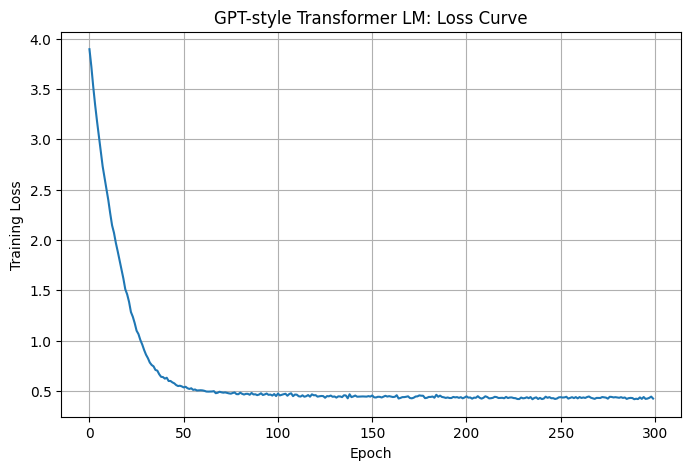

In [11]:
# Visualize Training Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GPT-style Transformer LM: Loss Curve")
plt.grid(True)
plt.show()


# Text Generation from Prompt

In [12]:

def generate_from_prompt(prompt: str, max_new_tokens: int = 10):
    """
    prompt: raw text, e.g. "neural networks"
    returns: completed text (string)
    """
    model.eval()
    with torch.no_grad():
        input_ids = encode_tokens(prompt)

        for _ in range(max_new_tokens):
            x = torch.tensor([input_ids], dtype=torch.long, device=device)
            logits = model(x)
            # take last timestep's logits
            next_id = int(logits[0, len(input_ids)-1].argmax().item())
            input_ids.append(next_id)
            if next_id == EOS_IDX:
                break

        return decode_tokens(input_ids)

# Quick sanity checks
print("\nQuick generations after training:\n")
for p in ["i love", "transformers are", "neural networks", "we train"]:
    print(f"Prompt: {p!r} ->", generate_from_prompt(p, max_new_tokens=8))



Quick generations after training:

Prompt: 'i love' -> i love machine learning
Prompt: 'transformers are' -> transformers are powerful models
Prompt: 'neural networks' -> neural networks can generate text
Prompt: 'we train' -> we train models with gradient descent


# Interactive Loop

In [13]:
# Interactive Loop

print("\nInteractive GPT-style text generator.")
print("Type the beginning of a sentence and I'll try to complete it.")
print("Press Enter on an empty line to quit.\n")

while True:
    user_prompt = input("Your prompt: ").strip()
    if user_prompt == "":
        print("Goodbye!")
        break

    completion = generate_from_prompt(user_prompt, max_new_tokens=10)
    print("Completion:", completion)
    print("-" * 60)



Interactive GPT-style text generator.
Type the beginning of a sentence and I'll try to complete it.
Press Enter on an empty line to quit.

Your prompt: I love
Completion: i love machine learning
------------------------------------------------------------
Your prompt: 
Goodbye!


# **Minimal Bidirectional Encoder Representations from Transformers (BERT)-Style Masked Language Model**

## *We will be using the BERT model to predict a missing word.!*

## 1. Overview

This implementation builds a simplified BERT-style masked language model using:

- A Transformer encoder

- Sinusoidal positional embeddings (as in the original BERT/Transformer paper)

- A dataset that generates one masked version per token

- A CLI interface to test masked predictions interactively

This example mirrors production-ready design patterns:

- configuration dataclass

- dataset class

- model class

- training loop

- inference utilities

- main() entry point

## 2. Imports and Header

We will use,
- python 3 forward-annotations for easier type hinting.
- dataclass is used for configuration.
- PyTorch is imported for tensor operations, neural network layers, optimizers, and data loaders.
- Dataset and DataLoader provide clean mini-batch processing.

In [14]:

"""
Minimal BERT-style Masked Language Model (Toy Dataset)

- Uses a Transformer encoder in PyTorch
- Trains by masking every token once per sentence
- Provides an interactive CLI: type a sentence with <mask> to get a prediction
"""

from __future__ import annotations

import math
import sys
from dataclasses import dataclass
from typing import List, Sequence, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader




## 3. Configuration Section

This dataclass holds all hyperparameters:

- Model parameters: embedding dimension, number of heads, number of layers, feed-forward dimension.

- Training parameters: batch size, learning rate, number of epochs.

- Special tokens: mask, pad, unknown.

Encapsulating these settings improves modularity and readability.

In [15]:
# Configuration


@dataclass
class Config:
    # Model
    d_model: int = 64
    nhead: int = 4
    num_layers: int = 2
    dim_ff: int = 128
    max_len: int = 50

    # Training
    batch_size: int = 8
    lr: float = 3e-3
    epochs: int = 200

    # Misc
    mask_token: str = "<mask>"
    pad_token: str = "<PAD>"
    unk_token: str = "<UNK>"




## 4. Data Utilities

A simple whitespace tokenizer. Converts input text into a list of lowercase tokens.

Vocabulary Builder
- Extracts all unique words.

- Ensures <mask> is included.

- Adds <PAD> and <UNK>.

- Builds:

      - stoi → string-to-index mapping

      - itos → index-to-string mapping

In [16]:

# Data utilities


def tokenize(text: str) -> List[str]:
    """Simple whitespace + lowercase tokenizer."""
    return text.lower().split()


def build_vocab(
    corpus: Sequence[str],
    cfg: Config,
) -> Tuple[dict, dict]:
    """
    Build vocabulary mappings from a raw corpus.

    Returns:
        stoi: token -> index
        itos: index -> token
    """
    # Collect unique tokens from corpus
    vocab_words = set()
    for s in corpus:
        vocab_words.update(tokenize(s))
    # Ensure special tokens exist
    vocab_words.add(cfg.mask_token)

    special = [cfg.pad_token, cfg.unk_token]
    itos = special + sorted(vocab_words)
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos




## Encoding and Padding
Here we have two functions that
- Converts tokens to integer IDs.
- Pads sequences to uniform length for batching.

In [17]:
def encode(tokens: Sequence[str], stoi: dict, unk_idx: int) -> List[int]:
    """Convert list of tokens to list of ids."""
    return [stoi.get(tok, unk_idx) for tok in tokens]


def pad_batch(seqs: Sequence[Sequence[int]], pad_value: int) -> torch.Tensor:
    """Pad a batch of integer sequences to the same length."""
    max_len = max(len(s) for s in seqs)
    padded = [list(s) + [pad_value] * (max_len - len(s)) for s in seqs]
    return torch.tensor(padded, dtype=torch.long)




## 5. Dataset Class: Masked Language Modeling

This dataset expands each sentence into multiple training samples:

- For each position in a sentence, replace that token with <mask>.

- Input: masked sentence

- Target: the original token

This replicates BERT’s masked language modeling objective.

Note: The collate function ensures minibatches are properly padded.

In [18]:
class MaskedLMDataset(Dataset):
    """
    Dataset for masked LM training.

    For each sentence in the corpus, for each token position i,
    we create a training example where position i is replaced with <mask>,
    and the label is the original token at position i.
    """

    def __init__(self, corpus: Sequence[str], stoi: dict, cfg: Config):
        self.cfg = cfg
        self.stoi = stoi
        self.pad_token = cfg.pad_token
        self.unk_token = cfg.unk_token
        self.mask_token = cfg.mask_token

        self.pad_idx = stoi[self.pad_token]
        self.unk_idx = stoi[self.unk_token]
        self.mask_idx = stoi[self.mask_token]

        self.inputs: List[List[int]] = []
        self.targets: List[int] = []

        for s in corpus:
            toks = tokenize(s)
            for pos in range(len(toks)):
                masked = toks.copy()
                original = toks[pos]
                masked[pos] = self.mask_token

                x_ids = encode(masked, self.stoi, self.unk_idx)
                y_id = self.stoi.get(original, self.unk_idx)

                self.inputs.append(x_ids)
                self.targets.append(y_id)

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Tuple[List[int], int]:
        return self.inputs[idx], self.targets[idx]

    def collate_fn(self, batch):
        inputs, targets = zip(*batch)
        x = pad_batch(inputs, pad_value=self.pad_idx)
        y = torch.tensor(targets, dtype=torch.long)
        return x, y




# 6. Model Components

Sinusoidal Positional Encoding:
Because Transformers have no recurrence or convolution. Positional encoding is used to inject token-location information.

Saving Positional encoding.png to Positional encoding (3).png


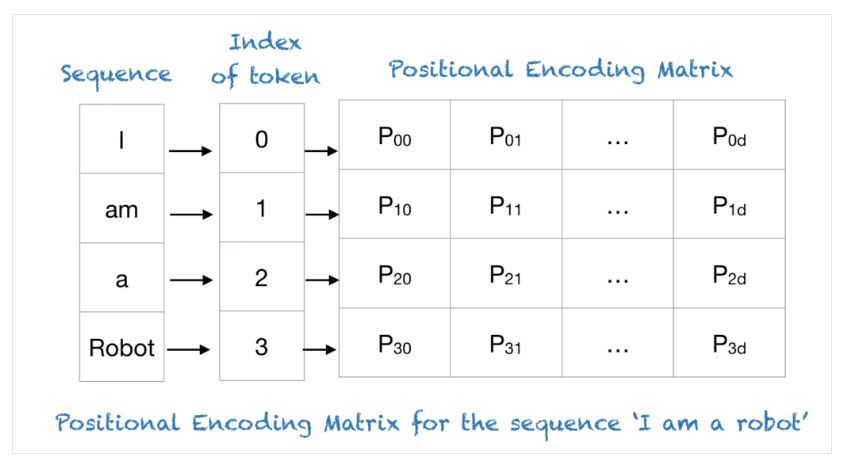

In [19]:
from google.colab import files
from IPython.display import Image
uploaded = files.upload()
Image("/content/Positional encoding.png")

This image is sourced from machinelearningmastery.com- on 25/11/2025.

In [20]:

# Model


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, D)
        """
        return x + self.pe[:, : x.size(1), :]





## Masked LM Model

Convert token IDs → embeddings (like in BERT).

- Add positional encodings.

- Transformer encoder processes entire sequence.

- Extract only the masked token’s embedding.

- Predict the vocabulary distribution for that token.

This corresponds exactly to the BERT MLM head.

In [21]:



class MaskedLM(nn.Module):
    """
    Minimal masked language model with a Transformer encoder.

    We assume exactly one <mask> token in each input sequence.
    """

    def __init__(self, vocab_size: int, mask_idx: int, pad_idx: int, cfg: Config):
        super().__init__()
        self.mask_idx = mask_idx
        self.pad_idx = pad_idx

        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=pad_idx)
        self.pos = PositionalEncoding(cfg.d_model, cfg.max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.nhead,
            dim_feedforward=cfg.dim_ff,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_layers)
        self.fc = nn.Linear(cfg.d_model, vocab_size)

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        """
        Args:
            src: (B, T) with exactly one mask token per row.

        Returns:
            logits: (B, V) logits for the masked positions only.
        """

  # Foward Pass
        pad_mask = src.eq(self.pad_idx)  # (B, T)

        x = self.emb(src)  # (B, T, D)
        x = self.pos(x)
        x = self.encoder(x, src_key_padding_mask=pad_mask)  # (B, T, D)

        # Get vectors at mask positions
        mask_positions = src.eq(self.mask_idx)  # (B, T)
        if not mask_positions.any():
            raise ValueError("No mask token found in input sequence.")

        x_mask = x[mask_positions]  # (B, D)
        logits = self.fc(x_mask)    # (B, V)
        return logits



# 7. Training Loop

- CrossEntropyLoss is appropriate for token classification.

- Every training sample predicts one masked token.

- Prints periodic loss for monitoring.

In [22]:

# Training / Inference


def train_model(
    model: MaskedLM,
    dataloader: DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
) -> None:
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0

        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)  # (B, V)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        if epoch % 40 == 0 or epoch == epochs - 1:
            avg_loss = total_loss / max(num_batches, 1)
            print(f"[Epoch {epoch:3d}] Loss: {avg_loss:.4f}")




# Inference Utility: Filling the Mask

- Encodes the sentence with <mask> included.

- Runs it through the model.

- Returns the highest probability token.

In [23]:
def fill_mask(
    model: MaskedLM,
    sentence: str,
    stoi: dict,
    itos: dict,
    cfg: Config,
    device: torch.device,
) -> str:
    """
    Fill the <mask> token in a sentence using the trained model.

    Args:
        sentence: sentence containing the literal token "<mask>"
        stoi: token -> id
        itos: id -> token
        cfg: configuration
        device: torch.device

    Returns:
        predicted token as string
    """
    model.eval()

    toks = tokenize(sentence)
    if cfg.mask_token not in toks:
        raise ValueError(f"Sentence must contain token {cfg.mask_token}")

    pad_idx = stoi[cfg.pad_token]
    unk_idx = stoi[cfg.unk_token]

    x_ids = encode(toks, stoi, unk_idx)
    x = pad_batch([x_ids], pad_value=pad_idx).to(device)

    with torch.no_grad():
        logits = model(x)[0]  # (V,)
        pred_id = int(logits.argmax().item())
    return itos[pred_id]


def interactive_loop(
    model: MaskedLM,
    stoi: dict,
    itos: dict,
    cfg: Config,
    device: torch.device,
) -> None:
    """
    Simple CLI loop to test the masked LM interactively.
    """
    print("\nInteractive masked LM. Type a sentence with <mask>. Empty line = quit.\n")

    while True:
        try:
            user_input = input("Your sentence: ")
        except (EOFError, KeyboardInterrupt):
            print("\nExiting...")
            break

        if not user_input or user_input.strip() == "":
            print("Goodbye!")
            break

        if cfg.mask_token not in user_input.lower():
            print(f"Please include the token {cfg.mask_token} in your sentence.")
            continue

        try:
            prediction = fill_mask(model, user_input, stoi, itos, cfg, device)
            print("→", prediction)
        except ValueError as e:
            print("Error:", e)
        print("-" * 40)




# 10. main(): Putting Everything Together

This block:

- loads corpus

- builds vocabulary

- constructs dataset and dataloader

- builds model

- trains

- performs quick tests

- launches interactive CLI

In [24]:

# Main entry point


def main() -> None:
    # Tiny toy corpus — replace or load from file in a real app
    corpus = [
        "neural networks can generate text",
        "transformers use self attention",
        "language models predict next words",
        "deep learning builds representations",
    ]

    cfg = Config()

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Build vocab
    stoi, itos_list = build_vocab(corpus, cfg)
    itos = {i: t for i, t in enumerate(itos_list)}

    print("Vocab size:", len(itos))
    print("Vocab:", stoi)

    # Dataset & dataloader
    dataset = MaskedLMDataset(corpus, stoi, cfg)
    dataloader = DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        collate_fn=dataset.collate_fn,
    )
    print("Number of training examples:", len(dataset))

    # Model
    mask_idx = stoi[cfg.mask_token]
    pad_idx = stoi[cfg.pad_token]
    model = MaskedLM(
        vocab_size=len(itos),
        mask_idx=mask_idx,
        pad_idx=pad_idx,
        cfg=cfg,
    )

    # Train
    train_model(model, dataloader, device, epochs=cfg.epochs, lr=cfg.lr)

    # Quick sanity tests
    print("\nQuick tests:")
    test_sentences = [
        "neural <mask> can generate text",
        "transformers use <mask> attention",
        "language models predict <mask> words",
        "deep <mask> builds representations",
    ]
    for s in test_sentences:
        try:
            print(s, "→", fill_mask(model, s, stoi, itos, cfg, device))
        except ValueError as e:
            print(s, "→ Error:", e)

    # Interactive CLI
    interactive_loop(model, stoi, itos, cfg, device)


if __name__ == "__main__":
    # Allow running as script. In production, you could expose train() and
    # fill_mask() as library functions and call them from an API.
    main()


Using device: cpu
Vocab size: 21
Vocab: {'<PAD>': 0, '<UNK>': 1, '<mask>': 2, 'attention': 3, 'builds': 4, 'can': 5, 'deep': 6, 'generate': 7, 'language': 8, 'learning': 9, 'models': 10, 'networks': 11, 'neural': 12, 'next': 13, 'predict': 14, 'representations': 15, 'self': 16, 'text': 17, 'transformers': 18, 'use': 19, 'words': 20}
Number of training examples: 18
[Epoch   0] Loss: 3.4222
[Epoch  40] Loss: 0.1233
[Epoch  80] Loss: 0.0112
[Epoch 120] Loss: 0.0091
[Epoch 160] Loss: 0.0273


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[Epoch 199] Loss: 0.0494

Quick tests:
neural <mask> can generate text → networks
transformers use <mask> attention → self
language models predict <mask> words → next
deep <mask> builds representations → learning

Interactive masked LM. Type a sentence with <mask>. Empty line = quit.

Your sentence: neural <mask> can generate text
→ networks
----------------------------------------
Your sentence: 
Goodbye!
